In [ ]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

[Learn the Basics](intro.html) \|\|
[Quickstart](quickstart_tutorial.html) \|\|
[Tensors](tensorqs_tutorial.html) \|\| [Datasets &
DataLoaders](data_tutorial.html) \|\|
[Transforms](transforms_tutorial.html) \|\| [Build
Model](buildmodel_tutorial.html) \|\|
[Autograd](autogradqs_tutorial.html) \|\| **Optimization** \|\| [Save &
Load Model](saveloadrun_tutorial.html)

Optimizing Model Parameters
===========================

Now that we have a model and data it\'s time to train, validate and test
our model by optimizing its parameters on our data. Training a model is
an iterative process; in each iteration the model makes a guess about
the output, calculates the error in its guess (*loss*), collects the
derivatives of the error with respect to its parameters (as we saw in
the [previous section](autogradqs_tutorial.html)), and **optimizes**
these parameters using gradient descent. For a more detailed walkthrough
of this process, check out this video on [backpropagation from
3Blue1Brown](https://www.youtube.com/watch?v=tIeHLnjs5U8).

Prerequisite Code
-----------------

We load the code from the previous sections on [Datasets &
DataLoaders](data_tutorial.html) and [Build
Model](buildmodel_tutorial.html).


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

Hyperparameters
===============

Hyperparameters are adjustable parameters that let you control the model
optimization process. Different hyperparameter values can impact model
training and convergence rates ([read
more](https://pytorch.org/tutorials/beginner/hyperparameter_tuning_tutorial.html)
about hyperparameter tuning)

We define the following hyperparameters for training:

:   -   **Number of Epochs** - the number of times to iterate over the
        dataset
    -   **Batch Size** - the number of data samples propagated through
        the network before the parameters are updated
    -   **Learning Rate** - how much to update models parameters at each
        batch/epoch. Smaller values yield slow learning speed, while
        large values may result in unpredictable behavior during
        training.


In [ ]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

Optimization Loop
=================

Once we set our hyperparameters, we can then train and optimize our
model with an optimization loop. Each iteration of the optimization loop
is called an **epoch**.

Each epoch consists of two main parts:

:   -   **The Train Loop** - iterate over the training dataset and try
        to converge to optimal parameters.
    -   **The Validation/Test Loop** - iterate over the test dataset to
        check if model performance is improving.

Let\'s briefly familiarize ourselves with some of the concepts used in
the training loop. Jump ahead to see the
`full-impl-label`{.interpreted-text role="ref"} of the optimization
loop.

Loss Function
-------------

When presented with some training data, our untrained network is likely
not to give the correct answer. **Loss function** measures the degree of
dissimilarity of obtained result to the target value, and it is the loss
function that we want to minimize during training. To calculate the loss
we make a prediction using the inputs of our given data sample and
compare it against the true data label value.

Common loss functions include
[nn.MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#torch.nn.MSELoss)
(Mean Square Error) for regression tasks, and
[nn.NLLLoss](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html#torch.nn.NLLLoss)
(Negative Log Likelihood) for classification.
[nn.CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss)
combines `nn.LogSoftmax` and `nn.NLLLoss`.

We pass our model\'s output logits to `nn.CrossEntropyLoss`, which will
normalize the logits and compute the prediction error.


In [ ]:
# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

Optimizer
=========

Optimization is the process of adjusting model parameters to reduce
model error in each training step. **Optimization algorithms** define
how this process is performed (in this example we use Stochastic
Gradient Descent). All optimization logic is encapsulated in the
`optimizer` object. Here, we use the SGD optimizer; additionally, there
are many [different
optimizers](https://pytorch.org/docs/stable/optim.html) available in
PyTorch such as ADAM and RMSProp, that work better for different kinds
of models and data.

We initialize the optimizer by registering the model\'s parameters that
need to be trained, and passing in the learning rate hyperparameter.


In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

Inside the training loop, optimization happens in three steps:

:   -   Call `optimizer.zero_grad()` to reset the gradients of model
        parameters. Gradients by default add up; to prevent
        double-counting, we explicitly zero them at each iteration.
    -   Backpropagate the prediction loss with a call to
        `loss.backward()`. PyTorch deposits the gradients of the loss
        w.r.t. each parameter.
    -   Once we have our gradients, we call `optimizer.step()` to adjust
        the parameters by the gradients collected in the backward pass.


Full Implementation {#full-impl-label}
===================

We define `train_loop` that loops over our optimization code, and
`test_loop` that evaluates the model\'s performance against our test
data.


In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

We initialize the loss function and optimizer, and pass it to
`train_loop` and `test_loop`. Feel free to increase the number of epochs
to track the model\'s improving performance.


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Further Reading
===============

-   [Loss
    Functions](https://pytorch.org/docs/stable/nn.html#loss-functions)
-   [torch.optim](https://pytorch.org/docs/stable/optim.html)
-   [Warmstart Training a
    Model](https://pytorch.org/tutorials/recipes/recipes/warmstarting_model_using_parameters_from_a_different_model.html)


Décris ta douleur (ou tape 'Quitter') : je perd les cheveux 
Prédiction : Mal de tête
Décris ta douleur (ou tape 'Quitter') : j ai mal à la bite le matin
Prédiction : Douleur au pied
Décris ta douleur (ou tape 'Quitter') : je me branle avec la main gauche au lieu de la droite 
Prédiction : Douleur au pied
Décris ta douleur (ou tape 'Quitter') : j'ai mal au pied
Prédiction : Mal de tête
Décris ta douleur (ou tape 'Quitter') : j'ai mal à la tete 
Prédiction : Douleur au pied
Décris ta douleur (ou tape 'Quitter') : j'ai mal à la tête
Prédiction : Douleur au pied
Décris ta douleur (ou tape 'Quitter') : j'ai mal aux couilles
Prédiction : Douleur au pied
Décris ta douleur (ou tape 'Quitter') : j'ai mal au pied
Prédiction : Mal de tête
Décris ta douleur (ou tape 'Quitter') : je n'ai pas mal 
Prédiction : Douleur au pied
Décris ta douleur (ou tape 'Quitter') : Mon front semble gonflé et douloureux
Prédiction : Mal de tête
Décris ta douleur (ou tape 'Quitter') : Mon front semble gonflé et doulo

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


data = pd.DataFrame({
    "text": [

        "pression au-dessus des yeux",
        "douleur avec la lumière",
        "sensibilité au bruit",
        "ça pulse fort",
        "je me sens étourdi",
        "tension dans le crâne",
        "douleur quand je regarde un écran",
        "migraine depuis ce matin",
        "lumière me gêne",
        "nausée avec douleur",
        "J’ai une pression constante juste au-dessus des yeux",

        "Une douleur pulsatile me serre les tempes",

        "J’ai l’impression qu’un étau comprime mon front",

        "Une sensation de battement derrière les yeux me gêne",

        "La zone autour de mon front brûle par moments",

        "Une douleur sourde irradie depuis mes tempes",

        "La lumière rend la douleur autour de mes yeux insupportable",

        "J’ai une sensation de lourdeur au niveau du front",

        "Une douleur vive traverse mes tempes par vagues",

        "J’ai l’impression qu’une pression interne pousse derrière mes yeux",

        "Le haut de mon visage semble compressé",

        "Une douleur lancinante se concentre autour de mes tempes",

        "Je ressens comme des coups de marteau derrière mes yeux",

        "Mon front semble pris dans un étau",

        "Une douleur diffuse envahit la partie supérieure de mon visage",

        "J’ai une sensation de pulsation au niveau des tempes",

        "La zone frontale me fait mal dès que je bouge",

        "Une douleur aiguë traverse l’espace entre mes sourcils",

        "Je sens une pression interne qui monte derrière mes yeux",

        "Mon front me brûle comme si j’avais de la fièvre",

        "Une douleur sourde s’étend de mes tempes vers ma nuque",

        "J’ai l’impression que mon front est trop serré",

        "Une douleur rythmée bat au niveau des tempes",

        "Je ressens une tension constante au-dessus de mes sourcils",

        "Une sensation de tiraillement envahit la zone frontale",

        "J’ai une douleur qui pulse derrière mes yeux",

        "Une pression écrasante s’installe sur mon front",

        "Je sens une douleur qui irradie autour de mes tempes",

        "La zone au-dessus de mes yeux est extrêmement sensible",

        "Une douleur vive apparaît dès que je me penche",

        "Mon front semble gonflé et douloureux",

        "Une douleur en casque entoure la partie supérieure de mon visage",

        "Je ressens une lourdeur écrasante au niveau frontal",

        "Une douleur électrique traverse mes tempes",

        "J’ai une sensation de chaleur douloureuse au-dessus des yeux",

        "Une douleur oppressante s’installe autour de mes tempes",

        "Je sens une pression interne qui ne cesse d’augmenter",

        "Une douleur en vague me traverse le front",

        "La zone frontale est douloureuse au toucher",

        "Une douleur pulsatile me réveille la nuit",

        "Je ressens une tension extrême autour de mes tempes",

        "Une douleur sourde s’installe derrière mes yeux",

        "Mon front semble compressé de l’intérieur",

        "Une douleur en arc se forme au-dessus de mes yeux",

        "Je sens une pression qui monte dès que je fais un effort",

        "Une douleur diffuse envahit la partie frontale",

        "Je ressens une pulsation douloureuse au niveau des tempes",

        "Une douleur aiguë apparaît quand je regarde la lumière",

        "Mon front semble pris dans une pression constante",

        "Une douleur battante se concentre derrière mes yeux",

        "Je sens une tension qui tire vers mes tempes",

        "Une douleur sourde s’installe au-dessus de mes sourcils",

        "Une sensation de compression envahit mon front",

        "Je ressens une douleur qui pulse au rythme de mon cœur",

        "Une douleur vive traverse la zone frontale",

        "Mon front est douloureux dès que je me lève",

        "Une pression interne me gêne derrière les yeux",

        "Une douleur en bande serre la partie supérieure de mon visage",

        "Je sens une douleur qui irradie vers mes tempes",

        "Une douleur lancinante s’installe au-dessus des yeux",

        "Mon front semble trop tendu",

        "Une douleur pulsatile me gêne dès le matin",

        "Je ressens une pression qui s’intensifie au niveau frontal",

        "Une douleur aiguë apparaît quand je tourne les yeux",

        "Une sensation de poids écrase mon front",

        "Une douleur sourde se propage autour de mes tempes",

        "Je sens une pulsation douloureuse derrière mes yeux",

        "Une douleur en étau entoure la zone frontale",

        "Mon front est douloureux comme si j’avais reçu un choc",

        "Une douleur diffuse s’installe au-dessus des yeux",

        "Je ressens une pression qui monte vers mes tempes",

        "Une douleur vive traverse mes tempes par moments",

        "Mon front semble comprimé par une force invisible",

        "Une douleur pulsatile me gêne en permanence",

        "Une sensation de tiraillement apparaît au niveau frontal",

        "Une douleur sourde se concentre derrière mes yeux",

        "Je sens une pression interne qui ne cesse de monter",

        "Une douleur en vague traverse mes tempes",

        "Mon front est douloureux dès que je parle",

        "Une douleur aiguë apparaît quand je me penche en avant",

        "Une pression écrasante s’installe au-dessus des yeux",

        "Je ressens une pulsation douloureuse au niveau frontal",

        "Une douleur diffuse envahit mes tempes",

        "Mon front semble brûlant et tendu",

        "Une douleur battante se manifeste derrière mes yeux",

        "Je sens une tension extrême au niveau frontal",

        "Une douleur sourde s’installe autour de mes tempes",

        "Une pression interne me gêne au-dessus des yeux",

        "Une douleur vive traverse la zone frontale",

        "Mon front semble pris dans un étau invisible",

        "Une douleur pulsatile me suit toute la journée",

        "Je ressens une pression qui s’intensifie derrière mes yeux",

        "Une douleur en bande serre mes tempes",

        "Une douleur sourde envahit la partie supérieure de mon visage",

        "Je sens une pulsation douloureuse au-dessus des sourcils",

        "Une douleur aiguë apparaît quand je bouge les yeux",

        "Une pression écrasante s’installe au niveau frontal",

        "Une douleur diffuse se propage autour de mes tempes",

        "Je ressens une tension constante au-dessus des yeux",

        "Une douleur battante traverse mes tempes sans arrêt",
        "J'ai mal au niveau de la tête",


        "douleur en marchant",
        "mal quand je pose le pied",
        "ça brûle sous le pied",
        "douleur en restant debout",
        "impossible de marcher longtemps",
        "ça tire quand je marche",
        "douleur après courir",
        "gonflement en bas",
        "douleur en montant les escaliers",
        "sensibilité quand je pose du poids",
        "J'ai mal au pied",

        "Mon tibia est rouge",
        "J’ai une douleur vive sous la plante quand je marche",

        "La zone sous ma cheville me lance à chaque pas",

        "J’ai une sensation de brûlure sous l’avant de ma jambe",

        "La partie inférieure de ma jambe me fait mal quand je me lève",

        "Une douleur aiguë apparaît dès que je pose le bas de ma jambe au sol",

        "J’ai une gêne sous la voûte quand je marche longtemps",

        "Une douleur me traverse le talon à chaque appui",

        "La zone sous mes orteils est très sensible",

        "J’ai une douleur qui irradie depuis le talon vers la cheville",

        "Une sensation de piqûre apparaît sous la plante",

        "Le dessous de ma jambe me fait mal dès le matin",

        "Une douleur sourde s’installe sous l’arrière de ma jambe",

        "J’ai une sensation de décharge électrique sous la plante",

        "Une douleur vive apparaît quand je plie mes orteils",

        "La zone sous mon talon est très douloureuse",

        "Une douleur me gêne sous l’avant de ma jambe",

        "J’ai une sensation de pression sous la plante",

        "Une douleur aiguë traverse la zone sous mes orteils",

        "La partie inférieure de ma jambe me brûle quand je marche",

        "Une douleur lancinante apparaît sous le talon",

        "J’ai une gêne sous la voûte plantaire",

        "Une douleur me traverse la plante à chaque pas",

        "La zone sous mes orteils semble enflammée",

        "Une douleur sourde s’installe sous le talon",

        "J’ai une sensation de tiraillement sous la plante",

        "Une douleur aiguë apparaît quand je me mets debout",

        "La partie basse de ma jambe me fait mal en marchant",

        "Une douleur me gêne sous la plante dès le réveil",

        "J’ai une sensation de brûlure sous le talon",

        "Une douleur vive traverse la zone sous mes orteils",

        "La zone inférieure de ma jambe est douloureuse au toucher",

        "Une douleur sourde apparaît sous la plante après l’effort",

        "J’ai une sensation de pression sous le talon",

        "Une douleur aiguë me gêne sous la voûte",

        "La partie basse de ma jambe me lance quand je marche vite",

        "Une douleur me traverse la plante quand je cours",

        "J’ai une sensation de piqûre sous l’avant de ma jambe",

        "Une douleur sourde s’installe sous le talon en fin de journée",

        "La zone sous mes orteils me fait mal quand je pousse sur la jambe",

        "Une douleur aiguë apparaît sous la plante quand je saute",

        "J’ai une sensation de tiraillement sous la voûte",

        "Une douleur me traverse le talon dès que je pose la jambe",

        "La partie inférieure de ma jambe semble enflammée",

        "Une douleur sourde apparaît sous la plante quand je reste debout",

        "J’ai une sensation de brûlure sous l’avant de la jambe",

        "Une douleur aiguë traverse la zone sous mes orteils",

        "La zone sous mon talon est très sensible",

        "Une douleur me gêne sous la plante quand je marche longtemps",

        "J’ai une sensation de pression sous la voûte plantaire",

        "Une douleur vive apparaît sous le talon au réveil",

        "La partie basse de ma jambe me fait mal quand je me penche",

        "Une douleur sourde s’installe sous la plante après une longue marche",

        "J’ai une sensation de piqûre sous le talon",

        "Une douleur aiguë me gêne sous la voûte",

        "La zone inférieure de ma jambe me lance à chaque pas",

        "Une douleur me traverse la plante quand je me déplace",

        "J’ai une sensation de brûlure sous la zone avant de ma jambe",

        "Une douleur sourde apparaît sous le talon en marchant",

        "La zone sous mes orteils est douloureuse quand je pousse",

        "Une douleur aiguë traverse la plante quand je me lève",

        "J’ai une sensation de tiraillement sous la voûte plantaire",

        "Une douleur me traverse le talon quand je marche vite",

        "La partie basse de ma jambe semble trop tendue",

        "Une douleur sourde apparaît sous la plante après l’effort",

        "J’ai une sensation de pression sous le talon",

        "Une douleur aiguë me gêne sous la voûte",

        "La zone inférieure de ma jambe me fait mal quand je cours",

        "Une douleur me traverse la plante quand je saute",

        "J’ai une sensation de piqûre sous l’avant de ma jambe",

        "Une douleur sourde s’installe sous le talon en fin de journée",

        "La zone sous mes orteils me fait mal quand je marche",

        "Une douleur aiguë apparaît sous la plante quand je me mets debout",

        "J’ai une sensation de tiraillement sous la voûte",

        "Une douleur me traverse le talon dès que je pose la jambe",

        "La partie inférieure de ma jambe semble enflammée",

        "Une douleur sourde apparaît sous la plante quand je reste debout",

        "J’ai une sensation de brûlure sous l’avant de la jambe",

        "Une douleur aiguë traverse la zone sous mes orteils",

        "La zone sous mon talon est très sensible",

        "Une douleur me gêne sous la plante quand je marche longtemps",

        "J’ai une sensation de pression sous la voûte plantaire",

        "Une douleur vive apparaît sous le talon au réveil",

        "La partie basse de ma jambe me fait mal quand je me penche",

        "Une douleur sourde s’installe sous la plante après une longue marche",

        "J’ai une sensation de piqûre sous le talon",

        "Une douleur aiguë me gêne sous la voûte",

        "La zone inférieure de ma jambe me lance à chaque pas",

        "Une douleur me traverse la plante quand je me déplace",

        "J’ai une sensation de brûlure sous la zone avant de ma jambe",

        "Une douleur sourde apparaît sous le talon en marchant",

        "La zone sous mes orteils est douloureuse quand je pousse",

        "Une douleur aiguë traverse la plante quand je me lève",

        "J’ai une sensation de tiraillement sous la voûte plantaire",

        "Une douleur me traverse le talon quand je marche vite",

        "La partie basse de ma jambe semble trop tendue",

        "Une douleur sourde apparaît sous la plante après l’effort",

        "J’ai une sensation de pression sous le talon",

        "Une douleur aiguë me gêne sous la voûte",

        "La zone inférieure de ma jambe me fait mal quand je cours",

        "Une douleur me traverse la plante quand je saute"
            ],

    "label": [0]*111 + [1]*112
})


In [29]:

X_train, X_test, y_train, y_test = train_test_split(
    data["text"], data["label"], test_size=0.2, random_state=42
)


vectorizer = TfidfVectorizer(
    ngram_range=(1,3),
    max_features=5000,
    stop_words=None
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)


y_pred = model.predict(X_test_vec)
print("Accuracy (test set) :", accuracy_score(y_test, y_pred))




Accuracy (test set) : 0.9111111111111111



Décris ta douleur (ou tape 'q') : j'ai mal à la tête
Problème à la tête  (confiance: 0.60)

Décris ta douleur (ou tape 'q') : tête
Problème à la tête  (confiance: 0.65)

Décris ta douleur (ou tape 'q') : q

Accuracy : 0.4


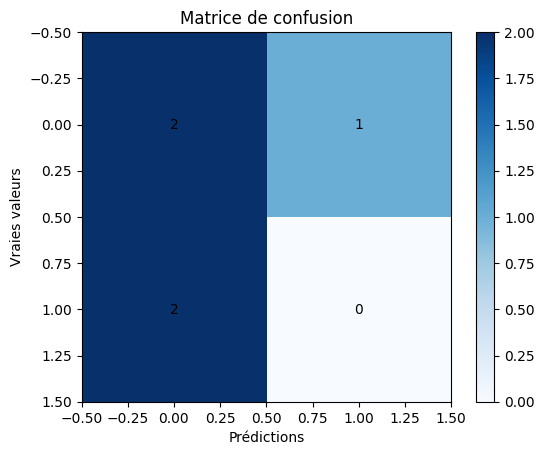

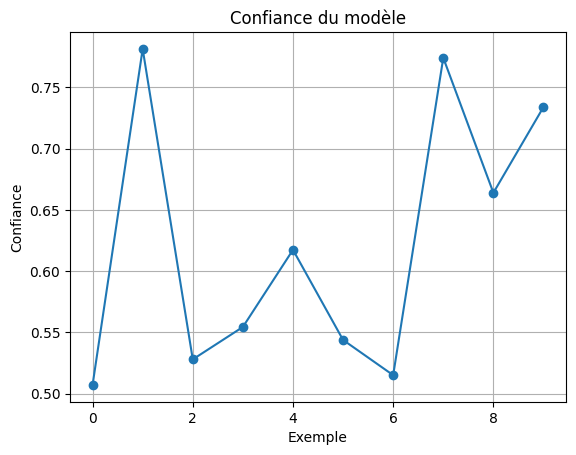

In [23]:
def predire_douleur(texte, seuil=0.55):
    vec = vectorizer.transform([texte])

    proba = model.predict_proba(vec)[0]
    confiance = np.max(proba)

    if confiance < seuil:
        return "Je ne sais pas ", None, confiance

    pred = np.argmax(proba)

    if pred == 0:
        return "Problème à la tête ", 0, confiance
    else:
        return "Problème au pied ", 1, confiance


'''test_auto = [
    ("j'ai mal au crâne", 0),
    ("pression derrière les yeux", 0),
    ("douleur quand je marche", 1),
    ("mon talon me fait mal", 1),
    ("je suis fatigué", None),
    ("j'ai de la fièvre", None),
    ("mes orteils brûlent", 1),
    ("ça tape dans mes tempes", 0),
    ("douleur au tibia", 1),
    ("mal autour des yeux", 0)
]

user_preds = []
user_labels = []

for texte, vrai in test_auto:
    prediction, pred_label, conf = predire_douleur(texte)'''


while True:
    user_input = input("\nDécris ta douleur (ou tape 'q') : ")
    if user_input == "q":
        break

    prediction, pred_label, conf = predire_douleur(user_input)

    print(f"{prediction} (confiance: {conf:.2f})")

if vrai is not None and pred_label is not None:
    user_preds.append(pred_label)
    user_labels.append(vrai)


if len(user_preds) > 0:
    acc = accuracy_score(user_labels, user_preds)
    print("\nAccuracy :", acc)


if len(user_preds) > 0:
    cm = confusion_matrix(user_labels, user_preds)

    plt.imshow(cm, cmap="Blues")
    plt.title("Matrice de confusion")
    plt.colorbar()
    plt.xlabel("Prédictions")
    plt.ylabel("Vraies valeurs")

    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.show()


confidences = []

for texte, _ in test_auto:
    _, _, conf = predire_douleur(texte)
    confidences.append(conf)

plt.plot(confidences, marker='o')
plt.title("Confiance du modèle")
plt.xlabel("Exemple")
plt.ylabel("Confiance")
plt.grid()
plt.show()


Décris ta douleur (ou tape 'q') : J'ai mal au tibia
Je ne sais pas prends un DOLIPRANE (confiance: 0.54)
Vrai label ? (0=tête, 1=pied, Enter=skip) : 

Décris ta douleur (ou tape 'q') : mon tibia me fais mal
Problème à la tête  (confiance: 0.56)
Vrai label ? (0=tête, 1=pied, Enter=skip) : 1

Décris ta douleur (ou tape 'q') : Mon tibia est  rouge
Je ne sais pas prends un DOLIPRANE (confiance: 0.52)
Vrai label ? (0=tête, 1=pied, Enter=skip) : 1

Décris ta douleur (ou tape 'q') : q

Accuracy : 0.0


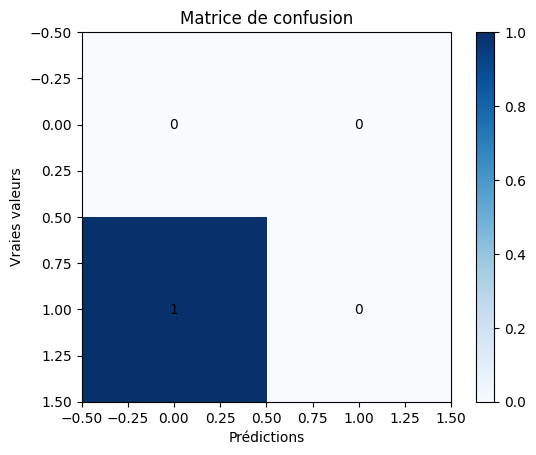

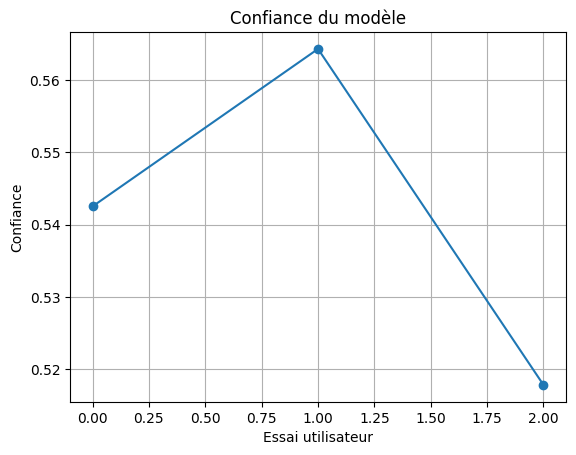

In [30]:
def predire_douleur(texte, seuil=0.55):
    vec = vectorizer.transform([texte])

    proba = model.predict_proba(vec)[0]
    confiance = np.max(proba)

    if confiance < seuil:
        return "Je ne sais pas prends un DOLIPRANE", None, confiance

    pred = np.argmax(proba)

    if pred == 0:
        return "Problème à la tête ", 0, confiance
    else:
        return "Problème au pied ", 1, confiance

user_preds = []
user_labels = []
confiance = []

while True:
    user_input = input("\nDécris ta douleur (ou tape 'q') : ")
    if user_input == "q":
        break

    prediction, pred_label, conf = predire_douleur(user_input)

    print(f"{prediction} (confiance: {conf:.2f})")

    confiance.append(conf)

    # 👇 Ask the correct label
    vrai = input("Vrai label ? (0=tête, 1=pied, Enter=skip) : ")

    if vrai != "":
        vrai = int(vrai)

        if pred_label is not None:
            user_preds.append(pred_label)
            user_labels.append(vrai)

if len(user_preds) > 0:
    acc = accuracy_score(user_labels, user_preds)
    print("\nAccuracy :", acc)

if len(user_preds) > 0:
    cm = confusion_matrix(user_labels, user_preds)

    plt.figure()
    plt.imshow(cm, cmap="Blues")
    plt.title("Matrice de confusion")
    plt.colorbar()

    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.xlabel("Prédictions")
    plt.ylabel("Vraies valeurs")
    plt.show()

plt.figure()
plt.plot(confiance, marker='o')
plt.title("Confiance du modèle")
plt.xlabel("Essai utilisateur")
plt.ylabel("Confiance")
plt.grid()
plt.show()